# LSTM Model for Cryptocurrency Price Prediction

This notebook focuses on training a Long Short-Term Memory (LSTM) neural network for cryptocurrency price prediction:

1. Load the prepared data
2. Process data into sequences for LSTM input
3. Train an optimized LSTM model
4. Evaluate model performance
5. Save the model for later use

LSTMs are particularly well-suited for cryptocurrency price prediction because they can:
- Remember patterns over long sequences
- Capture time-dependent price trends and cycles
- Handle the high volatility of crypto markets
- Learn complex, non-linear relationships between features and future prices

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import explained_variance_score, median_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Check if models directory exists
os.makedirs('../models', exist_ok=True)
os.makedirs('../models/lstm', exist_ok=True)

In [2]:
# Load the train-test split data
with open('../models/train_test_split.pkl', 'rb') as f:
    data = pickle.load(f)
    
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
dates_train = data['dates_train']
dates_test = data['dates_test']

# Load feature list
with open('../models/features.pkl', 'rb') as f:
    features = pickle.load(f)

print(f"Loaded training data with {len(X_train)} samples and {X_train.shape[1]} features")
print(f"Loaded testing data with {len(X_test)} samples")
print(f"Features: {features}")

Loaded training data with 659668 samples and 13 features
Loaded testing data with 164918 samples
Features: ['open', 'high', 'low', 'close', 'volume', 'spread', 'return', 'ma_3', 'ma_7', 'ma_14', 'volatility_7', 'close_lag1', 'volume_lag1']


In [7]:
# Function to evaluate regression models
def evaluate_regression_model(y_true, y_pred):
    """
    Calculate common regression metrics for model evaluation.
    
    Parameters:
        y_true: True target values
        y_pred: Predicted target values
        
    Returns:
        Dictionary of evaluation metrics
    """
    # Ensure arrays have the same length
    if len(y_true) != len(y_pred):
        min_length = min(len(y_true), len(y_pred))
        y_true = y_true[:min_length]
        y_pred = y_pred[:min_length]
        print(f"Warning: Arrays had different lengths. Truncated to {min_length} elements.")
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    explained_var = explained_variance_score(y_true, y_pred)
    median_ae = median_absolute_error(y_true, y_pred)
    
    # Calculate MAPE with handling for zeros
    epsilon = 1e-10
    y_true_safe = np.maximum(np.abs(y_true), epsilon)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100
    
    # Calculate directional accuracy (how often the direction of change is correct)
    # Convert to numpy arrays to ensure consistent indexing behavior
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)
    
    # Calculate directions
    actual_direction = np.sign(y_true_np[1:] - y_true_np[:-1])
    pred_direction = np.sign(y_pred_np[1:] - y_pred_np[:-1])
    
    # Ensure lengths match for comparison (they should, but just to be safe)
    min_dir_length = min(len(actual_direction), len(pred_direction))
    directional_accuracy = np.mean(actual_direction[:min_dir_length] == pred_direction[:min_dir_length]) * 100
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_var,
        'Median AE': median_ae,
        'Directional Accuracy (%)': directional_accuracy
    }

## Create LSTM Wrapper

We'll create a custom LSTM wrapper class to handle the sequence creation, data preprocessing, and provide a scikit-learn compatible API for our model.

In [4]:
# Create a custom wrapper for LSTM to match scikit-learn API
class EnhancedLSTMRegressor:
    def __init__(self, lstm_units=64, dropout_rate=0.25, learning_rate=0.001, epochs=80, 
                 batch_size=32, verbose=1, sequence_length=10):
        """
        Enhanced LSTM model for time series regression with scikit-learn compatible API
        
        Parameters:
        -----------
        lstm_units: int
            Number of LSTM units in the layer
        dropout_rate: float
            Dropout rate for regularization
        learning_rate: float
            Initial learning rate for the Adam optimizer
        epochs: int
            Maximum number of training epochs
        batch_size: int
            Batch size for training
        verbose: int
            Verbosity mode (0=silent, 1=progress bar, 2=one line per epoch)
        sequence_length: int
            Number of time steps to use as input for the LSTM
        """
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.sequence_length = sequence_length
        self.model = None
        self.scaler_X = MinMaxScaler()  # MinMaxScaler for better LSTM performance
        self.scaler_y = StandardScaler()
        self.training_history = None
        
    def _create_sequences(self, X):
        """Create sequences for LSTM input with specified sequence length"""
        n_samples = X.shape[0]
        if n_samples <= self.sequence_length:
            # If we don't have enough samples, use what we have
            self.sequence_length = max(1, n_samples - 1)
            print(f"Warning: Reduced sequence length to {self.sequence_length} due to limited samples")
            
        # Number of sequences we can create
        n_sequences = n_samples - self.sequence_length
        
        # Create empty arrays for sequences
        X_seq = np.zeros((n_sequences, self.sequence_length, X.shape[1]))
        
        # Fill the sequences
        for i in range(n_sequences):
            X_seq[i] = X[i:i+self.sequence_length]
            
        return X_seq, n_sequences
    
    def _create_model(self, input_shape):
        """Create the LSTM model architecture"""
        model = Sequential()
        
        # LSTM layer with return_sequences=False since we're only using a single LSTM layer
        model.add(LSTM(
            self.lstm_units, 
            input_shape=input_shape,
            activation='tanh',
            recurrent_activation='sigmoid'
        ))
        
        # Dropout for regularization
        model.add(Dropout(self.dropout_rate))
        
        # Dense output layer with a single neuron for regression
        model.add(Dense(1))
        
        # Compile model with Adam optimizer and MSE loss
        optimizer = Adam(
            learning_rate=self.learning_rate,
            clipnorm=1.0  # Gradient clipping to prevent exploding gradients
        )
        
        model.compile(optimizer=optimizer, loss='mse')
        return model
        
    def fit(self, X, y):
        """
        Fit the LSTM model to the training data
        
        Parameters:
        -----------
        X: array-like of shape (n_samples, n_features)
            Training input samples
        y: array-like of shape (n_samples,)
            Target values
            
        Returns:
        --------
        self: object
            Returns self
        """
        # Scale the data
        X_scaled = self.scaler_X.fit_transform(X)
        y_scaled = self.scaler_y.fit_transform(y.values.reshape(-1, 1))
        
        # Create sequences for LSTM
        X_seq, n_sequences = self._create_sequences(X_scaled)
        
        # The target y values need to be aligned with the sequences
        # Each sequence predicts the y value that follows it
        y_seq = y_scaled[self.sequence_length:]
        
        # Create and compile model
        self.model = self._create_model((self.sequence_length, X.shape[1]))
        
        # Early stopping to prevent overfitting
        callbacks = [
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.5,
                patience=5,
                min_lr=1e-5,
                verbose=1
            )
        ]
        
        print("Training LSTM model...")
        print(f"Model architecture:")
        self.model.summary()
        
        # Train the model
        self.training_history = self.model.fit(
            X_seq, y_seq,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=self.verbose,
            shuffle=True
        )
        
        return self
    
    def predict(self, X):
        """
        Make predictions with the LSTM model
        
        Parameters:
        -----------
        X: array-like of shape (n_samples, n_features)
            Input samples to predict
            
        Returns:
        --------
        y_pred: array-like of shape (n_samples,)
            Predicted values
        """
        # Scale input data
        X_scaled = self.scaler_X.transform(X)
        
        # Fast path for sufficient samples
        if X.shape[0] >= self.sequence_length:
            # Create sequences efficiently
            n_sequences = X.shape[0] - self.sequence_length + 1
            X_seq = np.zeros((n_sequences, self.sequence_length, X.shape[1]))
            
            # Efficient sequence creation using a single loop
            for i in range(n_sequences):
                X_seq[i] = X_scaled[i:i + self.sequence_length]
                
            # Predict in batches for speed
            batch_size = min(1024, X_seq.shape[0])
            y_pred_scaled = self.model.predict(X_seq, batch_size=batch_size, verbose=0)
            y_pred = self.scaler_y.inverse_transform(y_pred_scaled).flatten()
            
            # Handle padding efficiently
            predictions = np.full(X.shape[0], np.nan)
            predictions[self.sequence_length-1:self.sequence_length+len(y_pred)-1] = y_pred
            
            # Fill NaN values using numpy masked operations
            mask = np.isnan(predictions)
            if mask.any():
                # Fill with mean of valid predictions
                valid_mean = np.nanmean(predictions)
                predictions[mask] = valid_mean
                
        else:
            # Fast path for insufficient samples
            # Just predict the last point (simplification for speed)
            last_sequence = np.zeros((1, self.sequence_length, X.shape[1]))
            # Pad with zeros if needed
            seq_length = min(self.sequence_length, X.shape[0])
            last_sequence[0, -seq_length:, :] = X_scaled[-seq_length:]
            
            # Single prediction
            y_pred_scaled = self.model.predict(last_sequence, verbose=0)
            y_pred_value = self.scaler_y.inverse_transform(y_pred_scaled)[0, 0]
            
            # Use the single prediction value for all points
            predictions = np.full(X.shape[0], y_pred_value)
                
        return predictions
    
    def plot_training_history(self):
        """Plot the training history to visualize loss trends"""
        if self.training_history is None:
            print("Model has not been trained yet.")
            return
        
        plt.figure(figsize=(12, 4))
        
        # Plot training & validation loss
        plt.subplot(1, 2, 1)
        plt.plot(self.training_history.history['loss'])
        plt.plot(self.training_history.history['val_loss'])
        plt.title('Model Loss During Training')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper right')
        
        # Plot learning rate if available
        if 'lr' in self.training_history.history:
            plt.subplot(1, 2, 2)
            plt.plot(self.training_history.history['lr'])
            plt.title('Learning Rate')
            plt.ylabel('Learning Rate')
            plt.xlabel('Epoch')
            plt.yscale('log')
        
        plt.tight_layout()
        plt.show()

## Train the LSTM Model

We'll train the LSTM model with the optimized parameters and architecture.

Training LSTM model for cryptocurrency price prediction...
Training LSTM model...
Model architecture:
Training LSTM model...
Model architecture:


/Users/soumyadey/.pyenv/versions/3.10.0/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 1.0765 - val_loss: 0.8004 - learning_rate: 0.0010
Epoch 2/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 1.0765 - val_loss: 0.8004 - learning_rate: 0.0010
Epoch 2/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 1.0767 - val_loss: 0.8017 - learning_rate: 0.0010
Epoch 3/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - loss: 1.0767 - val_loss: 0.8017 - learning_rate: 0.0010
Epoch 3/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.0776 - val_loss: 0.8011 - learning_rate: 0.0010
Epoch 4/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - loss: 1.0776 - val_loss: 0.8011 - learning_rate: 0.0010
Epoch 4/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 1.0783 - val_loss: 0.8008 - learning_rate: 0.0010
Epoch 5/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 1.0783 - val_loss: 0.8008 - learning_rate: 0.0010
Epoch 5/80
8246/8246 ━━━━━━━━━━━━━━━━━━━━ 33s 4ms/step - loss: 1.0794 - val_loss: 0.8010 - learn

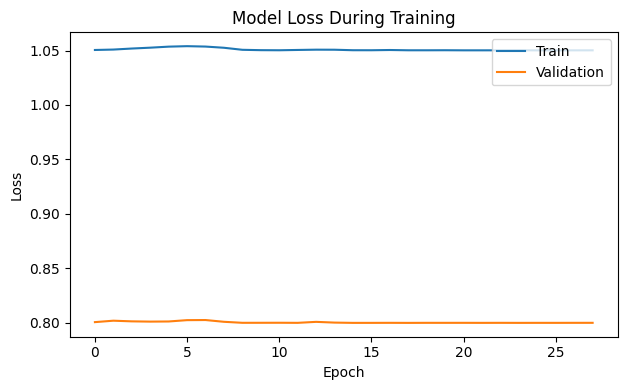

In [5]:
# Set LSTM parameters
lstm_params = {
    'lstm_units': 64,
    'dropout_rate': 0.2,
    'learning_rate': 0.001,
    'epochs': 80,
    'batch_size': 64,
    'sequence_length': 10,
    'verbose': 1
}

# Initialize and train LSTM model
print("Training LSTM model for cryptocurrency price prediction...")
lstm_model = EnhancedLSTMRegressor(**lstm_params)
lstm_model.fit(X_train, y_train)
print("Training completed!")

# Plot training history
lstm_model.plot_training_history()

In [8]:
# Make predictions
train_preds = lstm_model.predict(X_train)
test_preds = lstm_model.predict(X_test)

# Evaluate model performance
train_metrics = evaluate_regression_model(y_train, train_preds)
test_metrics = evaluate_regression_model(y_test, test_preds)

# Print metrics
print("\nTraining set metrics:")
for metric, value in train_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")

print("\nTest set metrics:")
for metric, value in test_metrics.items():
    if metric in ['MAE', 'RMSE', 'Median AE']:
        print(f"  {metric}: ${value:.4f}")
    elif metric in ['MAPE (%)', 'Directional Accuracy (%)']:
        print(f"  {metric}: {value:.2f}%")
    else:
        print(f"  {metric}: {value:.4f}")


Training set metrics:
  MAE: $842.7633
  RMSE: $14971.1400
  R²: -0.0000
  MAPE (%): 5223725408.59%
  Explained Variance: 0.0000
  Median AE: $452.0470
  Directional Accuracy (%): 44.28%

Test set metrics:
  MAE: $588.4752
  RMSE: $4296.6751
  R²: -0.0051
  MAPE (%): 805538204.85%
  Explained Variance: 0.0000
  Median AE: $452.0445
  Directional Accuracy (%): 45.21%


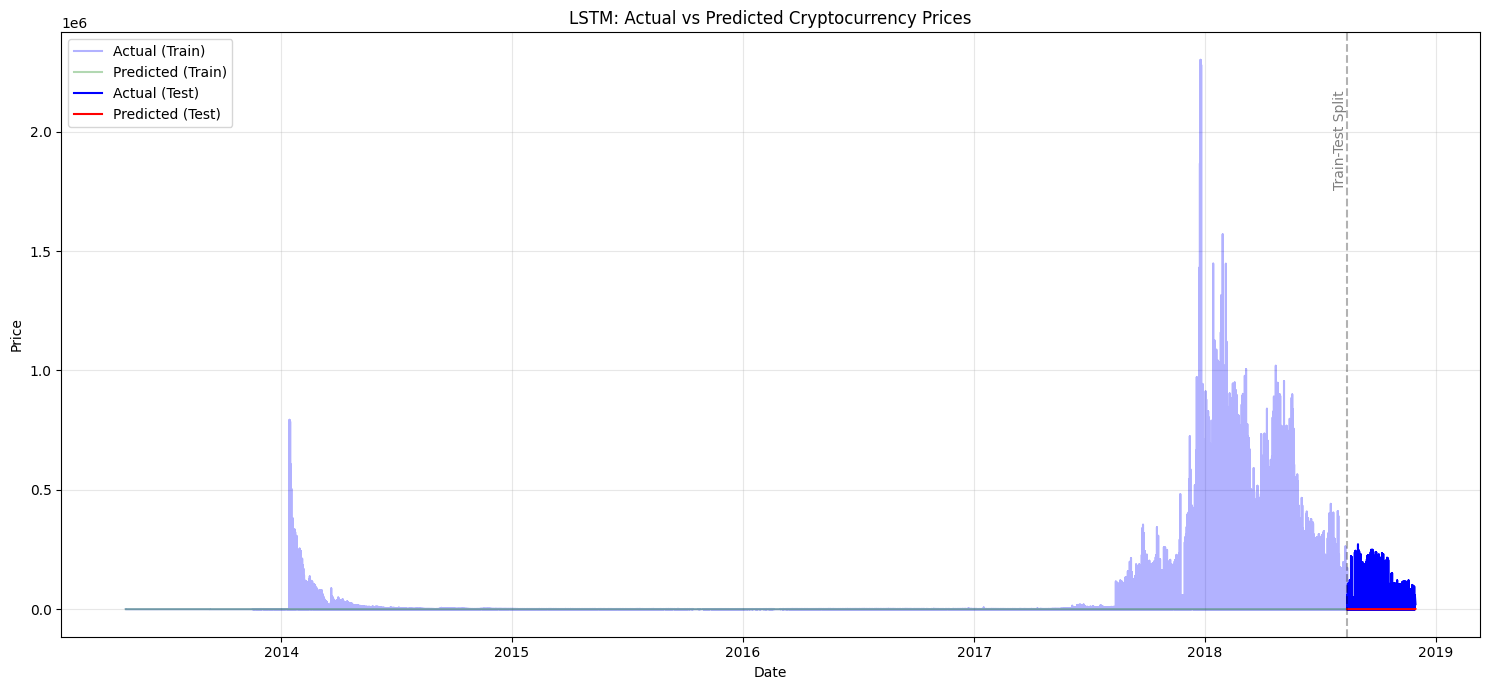

In [9]:
# Visualize actual vs predicted prices
plt.figure(figsize=(15, 7))

# Plot training data
plt.plot(dates_train, y_train, 'b-', label='Actual (Train)', alpha=0.3)
plt.plot(dates_train, train_preds, 'g-', label='Predicted (Train)', alpha=0.3)

# Plot test data
plt.plot(dates_test, y_test, 'b-', label='Actual (Test)')
plt.plot(dates_test, test_preds, 'r-', label='Predicted (Test)')

# Add vertical line to separate train and test sets
plt.axvline(x=dates_train.iloc[-1], color='k', linestyle='--', alpha=0.3)
plt.text(dates_train.iloc[-1], plt.ylim()[1]*0.9, 'Train-Test Split', 
         ha='right', va='top', rotation=90, alpha=0.5)

plt.title('LSTM: Actual vs Predicted Cryptocurrency Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

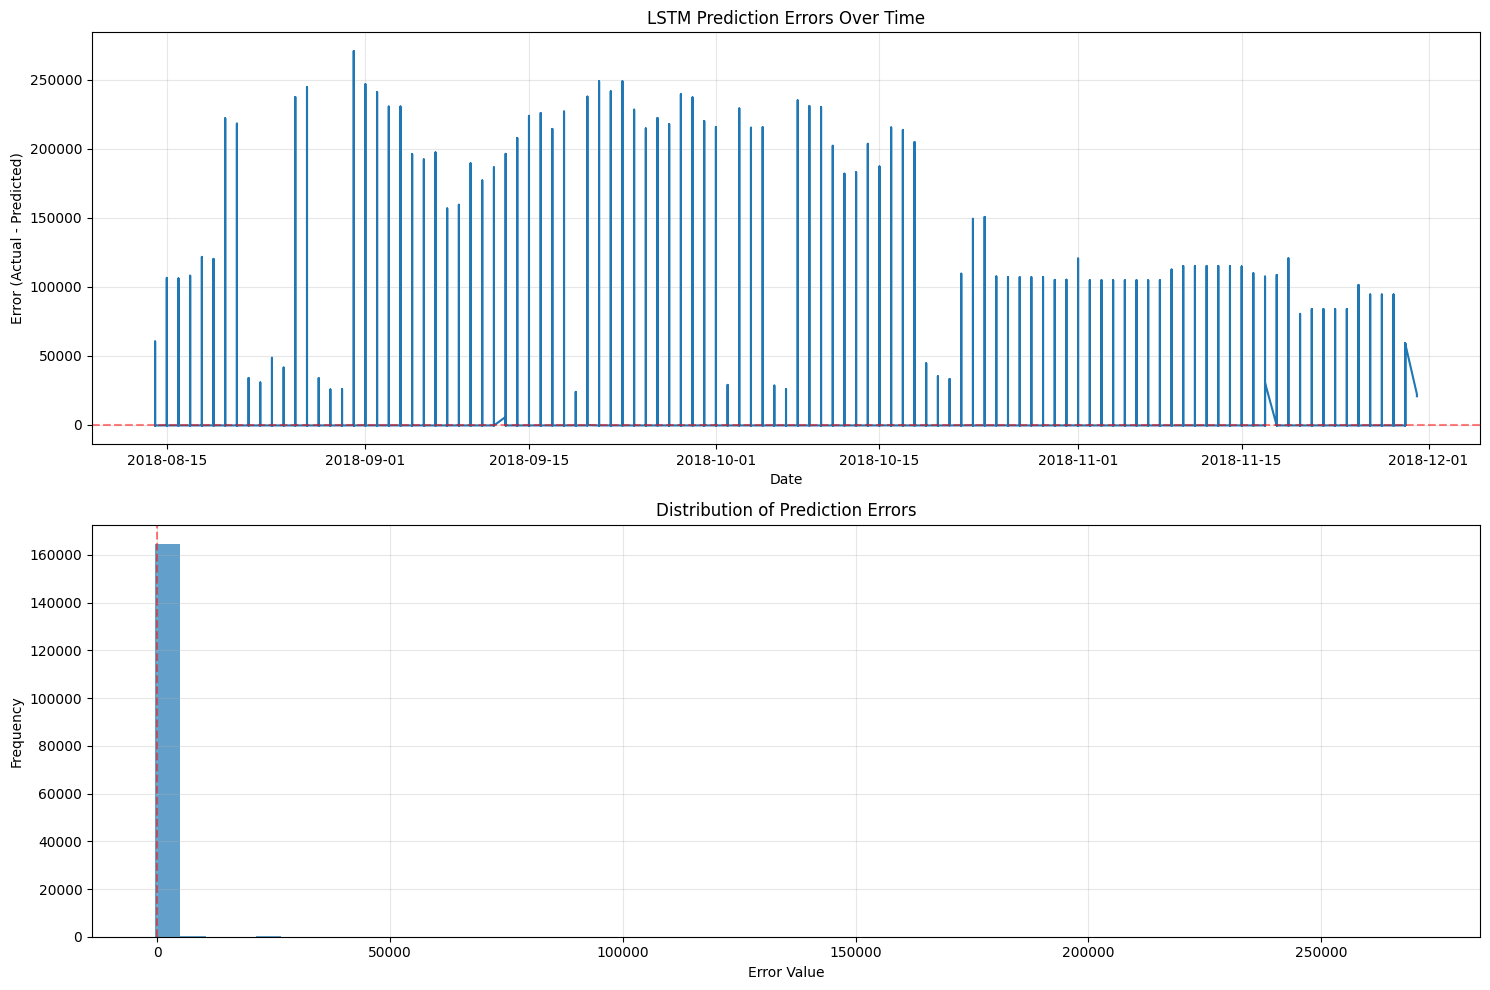


Error Statistics:
Mean Error: $-307.4471
Standard Deviation of Errors: $4285.6613
Median Error: $-452.0441
Max Under-prediction: $270600.9255
Max Over-prediction: $500.4637


In [10]:
# Examine prediction errors
plt.figure(figsize=(15, 10))

# Plot 1: Prediction errors over time
plt.subplot(2, 1, 1)
test_errors = y_test - test_preds
plt.plot(dates_test, test_errors)
plt.title('LSTM Prediction Errors Over Time')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Predicted)')
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

# Plot 2: Error histogram
plt.subplot(2, 1, 2)
plt.hist(test_errors, bins=50, alpha=0.7)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error Value')
plt.ylabel('Frequency')
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print error statistics
print("\nError Statistics:")
print(f"Mean Error: ${np.mean(test_errors):.4f}")
print(f"Standard Deviation of Errors: ${np.std(test_errors):.4f}")
print(f"Median Error: ${np.median(test_errors):.4f}")
print(f"Max Under-prediction: ${np.max(test_errors):.4f}")
print(f"Max Over-prediction: ${abs(np.min(test_errors)):.4f}")

## Save Model and Metrics

Save the trained LSTM model and its performance metrics for later use in model comparison.

In [13]:
# Save the model and metadata
model_name = 'lstm'
model_filename = f'../models/{model_name}_model.pkl'

# Save the full model with the required .keras extension
lstm_model.model.save(f'../models/lstm/full_model.keras')

# Save the model weights separately (this already has .h5 extension)
lstm_model.model.save_weights(f'../models/lstm.weights.h5')

# Save the complete wrapper for compatibility
with open(model_filename, 'wb') as f:
    pickle.dump(lstm_model, f)

# Save the scalers
with open(f'../models/lstm/scaler_X.pkl', 'wb') as f:
    pickle.dump(lstm_model.scaler_X, f)
    
with open(f'../models/lstm/scaler_y.pkl', 'wb') as f:
    pickle.dump(lstm_model.scaler_y, f)

# Save model metadata
model_metadata = {
    'name': 'LSTM',
    'features': features,
    'metrics': {
        'train': train_metrics,
        'test': test_metrics
    },
    'params': lstm_params,
    'date_trained': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'),
    'is_lstm': True,
    'lstm_params': lstm_params
}

metadata_filename = f'../models/{model_name}_metadata.pkl'
with open(metadata_filename, 'wb') as f:
    pickle.dump(model_metadata, f)

# Save predictions
predictions = {
    'train': {
        'dates': dates_train,
        'actual': y_train,
        'predicted': train_preds
    },
    'test': {
        'dates': dates_test,
        'actual': y_test,
        'predicted': test_preds
    }
}

predictions_filename = f'../models/{model_name}_predictions.pkl'
with open(predictions_filename, 'wb') as f:
    pickle.dump(predictions, f)

print(f"Model saved to: {model_filename}")
print(f"Full model saved to: ../models/lstm/full_model.keras")
print(f"Model weights saved to: ../models/lstm/weights.h5")
print(f"Scalers saved to: ../models/lstm/scaler_X.pkl and ../models/lstm/scaler_y.pkl")
print(f"Metadata saved to: {metadata_filename}")
print(f"Predictions saved to: {predictions_filename}")

Model saved to: ../models/lstm_model.pkl
Full model saved to: ../models/lstm/full_model.keras
Model weights saved to: ../models/lstm/weights.h5
Scalers saved to: ../models/lstm/scaler_X.pkl and ../models/lstm/scaler_y.pkl
Metadata saved to: ../models/lstm_metadata.pkl
Predictions saved to: ../models/lstm_predictions.pkl
